In [1]:
from __future__ import division, print_function

import ROOT

import os, sys
import math
import collections
import copy
import json

ANA_DIR = os.path.expanduser("~/nobackup/bbtautau_afresh/CMSSW_15_0_15/src/Ana")
os.chdir(ANA_DIR)
sys.path.insert(0, ANA_DIR)

ROOT.gInterpreter.AddIncludePath(ANA_DIR)  
ROOT.gROOT.LoadMacro("Particle.h+")
ROOT.gROOT.LoadMacro("HHbbtautauAnaElements.C+")

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

ROOT.gErrorIgnoreLevel = ROOT.kInfo  # show more
# ROOT.ROOT.EnableImplicitMT(0)        # avoid MT confusing errors

import anaConfig
from ROOT import Ana, TCanvas, TH1D, TPad, TLegend, THStack, RDataFrame
from argparse import ArgumentParser


CWD = /uscms_data/d3/adas1/bbtautau_afresh/CMSSW_15_0_15/src/Ana
sys.path[0] = /uscms/home/adas1/nobackup/bbtautau_afresh/CMSSW_15_0_15/src/Ana


Info in <ACLiC>: script has already been loaded in interpreted mode
Info in <ACLiC>: unloading /uscms_data/d3/adas1/bbtautau_afresh/CMSSW_15_0_15/src/Ana/./FileFlow.h and compiling it
Info in <ACLiC>: unmodified script has already been compiled and loaded


In [2]:
DATASET_DICT_PATH = "dataset_dict/"


def ls_nanoaod_files(
        year, dataset_dict_path,     
        category = "HHbbtt", 
        sample = "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",
        verbose=0
    ):
    """
    Load index JSON for a given YEAR from the project root/data directory.

    Returns:
        Parsed JSON object (dict or list depending on file contents).
    """
    # Base directories
    json_file = os.path.join(dataset_dict_path, f"index_{year}.json")

    # Load JSON
    with open(json_file, "r") as f:
        data = json.load(f)
        categories = sorted(data.keys())

        if verbose:
            print(f"[{year}] Available categories:")
            for cat in categories:
                print("  -", cat)

        if category not in data:
            raise ValueError(
                f"Category '{category}' not found for {year}. "
                f"Available: {', '.join(sorted(data.keys()))}"
            )

        cat_dict = data[category]
        if sample not in cat_dict:
            raise ValueError(
                f"Sample '{sample}' not found in category '{category}' for {year}. "
                f"Available: {', '.join(sorted(cat_dict.keys()))}"
            )

        files = cat_dict[sample]
        if verbose:
            print(f"[{year}] Category '{category}', sample '{sample}':")
            print(f"  Number of files: {len(files)}")
        return files

In [3]:
YEAR = 2022
CATEGORY = "HHbbtt"
SAMPLE="GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",

files = ls_nanoaod_files(
    year = YEAR,
    dataset_dict_path=DATASET_DICT_PATH, 
    category = "HHbbtt", 
    # sample = "GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00",
    sample = "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",
    verbose=True
    )

[2022] Available categories:
  - EGamma
  - HH4b
  - HHbbtt
  - Hbb
  - JetMET
  - Muon
  - QCD
  - SingleTop
  - TT
  - Tau
  - VJets
  - diboson
[2022] Category 'HHbbtt', sample 'GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00':
  Number of files: 30


In [6]:
YEAR = 2022
CATEGORY = "HHbbtt"
SAMPLE="GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",
SHORT_NAME = "ggfBoostedPrivate"

files = ls_nanoaod_files(
    year = YEAR,
    dataset_dict_path=DATASET_DICT_PATH, 
    category = "HHbbtt", 
    sample = "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",
    verbose=True
    )

[2022] Available categories:
  - EGamma
  - HH4b
  - HHbbtt
  - Hbb
  - JetMET
  - Muon
  - QCD
  - SingleTop
  - TT
  - Tau
  - VJets
  - diboson
[2022] Category 'HHbbtt', sample 'GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00':
  Number of files: 30


In [8]:
def dropBranchNames(frame, filename, exclusionlist = []):
	"""
	Writes a list of column (branch) names from a ROOT RDataFrame to a text file,
	excluding any branches whose names contain substrings in the exclusion list.

	Parameters:
		frame         : ROOT.RDataFrame
			The dataframe to extract column names from.
		filename      : str
			The name of the output text file where the column names will be saved.
		exclusionlist : list of str
			List of substrings; any column containing these substrings will be excluded.
	"""
	with open(filename, "w") as file: 
		for name in frame.GetColumnNames(): 
			name = str(name)
			#print("{} {}".format(name, [(excluded in name) for excluded in exclusionlist]))
			if not (any([excluded in name for excluded in exclusionlist])): 
				file.write("{}\n".format(name))

def generalise(df): 
	return ROOT.ROOT.RDF.AsRNode(df)


In [ ]:
sig = ROOT.RDataFrame("Events", files)
sig = sig.Range(0, 500000)
sig = generalise(sig)

ROOT.gStyle.SetOptStat(0)
ROOT.RDF.Experimental.AddProgressBar(sig)
print(sig)

<cppyy.gbl.ROOT.RDF.RInterface<ROOT::Detail::RDF::RNodeBase,void> object at 0x18df1e10>


In [17]:
# Creates file with the name branchnames.txt
dropBranchNames(sig, "branchnames.txt", ["L1", "HLT", "DST"])

In [21]:
#sig = Ana.GetP4(sig, "Muon") #sig = Ana.GetP4["float"](sig, "Muon")
#sig = Ana.GetGenParticles(sig, "Muon")
#sig = Ana.GetGenParticles(sig, "Electron")

genprefix = "GenPart"

cutflow = ROOT.CutFlow("cutflow", "Selection cutflow")

n0 = sig.Count().GetValue()
cutflow.Increment("Initial", n0)

sig = sig.Filter("nFatJet>=2").Filter("FatJet_pt[0]>250&&FatJet_pt[1]>200")

n1 = sig.Count().GetValue()
cutflow.Add("jet selection", n1)

print(n0, n1)

23217 23217


In [12]:
sig = sig.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
#sig = sig.Define("TheGenMuon_pt", "Ana::overflowProtected(GenPart_pt, GenDecay.mu)").Define("TheGenMuon_eta", "GenPart_eta[GenDecay.mu]").Define("TheGenMuon_phi", "GenPart_phi[GenDecay.mu]")
sig = sig.Define("dR_mu_gen", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass, {1}_pdgId, \"{1}\")".format("GenPart", "Muon"))
sig = sig.Define("closest_mu_gen", "Ana::closestMatch(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass, {1}_pdgId, \"{1}\")".format("GenPart", "Muon"))
sig = sig.Define("closest_mu_FatJet", "Ana::closestMatch(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
sig = sig.Define("dR_mu_FatJet", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
sig = sig.Define("dR_HH", "Ana::deltaR(GenDecay.Htotau, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.Htob)".format("GenPart"))
sig = sig.Define("dR_tautau", "Ana::deltaR(GenDecay.tau1, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.tau2)".format("GenPart"))

hh = sig.Filter("GenDecay.decayType==1")
hm = sig.Filter("GenDecay.decayType==2")
n2 = hm.Count().GetValue()
cutflow.Add("tauh taumu", n2)

hm = hm.Define("dR_mu_FatJet_hm", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
hi = hm.Filter("dR_mu_FatJet_hm<0.8&&dR_mu_FatJet_hm>0")
n3 = hi.Count().GetValue()
cutflow.Add("gen mu in jet", n3)

hi = hi.Define("TheRecoMuon", "closest_mu_gen")
hi = hi.Define("TheRecoMuon_pt", "Muon_pt[TheRecoMuon]")
hi = hi.Filter("Muon_tightId[TheRecoMuon]")
n4 = hi.Count().GetValue()
cutflow.Add("reco mu matched", n4)

hi = hi.Filter("Muon_pt[TheRecoMuon]>20&&abs(Muon_eta[TheRecoMuon])<2.4&&Muon_dz[TheRecoMuon]<0.2&&Muon_dxy[TheRecoMuon]<0.05")
n5 = hi.Count().GetValue()
cutflow.Add("muon sel", n5)

#hh = hh.Define("dR_tautau", "Ana::deltaR(GenDecay.tau1, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.tau2)".format("GenPart"))

N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Tau (mother = 15), 8451 (status)
Tau: -15 (id), Tau (mother = -15), 8451 (status)
N bs: 2
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Tau (mother = 15), 8451 (status)
Tau: -15 (id), Tau (mother = -15), 8451 (status)
N bs: 2
N bs: 2
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: -15 (id), Tau (mother = -15), 8451 (status)
Tau: 15 (id), Tau (mother = 15), 8451 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Tau (mother = 15), 8451 (status)
Tau: -15 (id

In [13]:
# blacklist = ["Muon_P4", "GenPart_Particle", "GenMuon", "HLT*", "L1*"] # TODO: add autoblacklist

# sig.Snapshot("Events", "./SigAll.root", Ana.purgeColumns(sig.GetColumnNames(), blacklist))
# hh.Snapshot("Events", "./Sighh.root", Ana.purgeColumns(hh.GetColumnNames(), blacklist))
# hm.Snapshot("Events", "./Sighm.root", Ana.purgeColumns(hm.GetColumnNames(), blacklist))
# hi.Snapshot("Events", "./Sigwithproxy.root", Ana.purgeColumns(hi.GetColumnNames(), blacklist))

# print("Initial: {}, 2 FatJets: {}, tauhtaumu: {}, gen mu within jet: {}, reco mu within jet: {}, other selection requirements: {}".format(n0, n1, n2, n3, n4, n5))

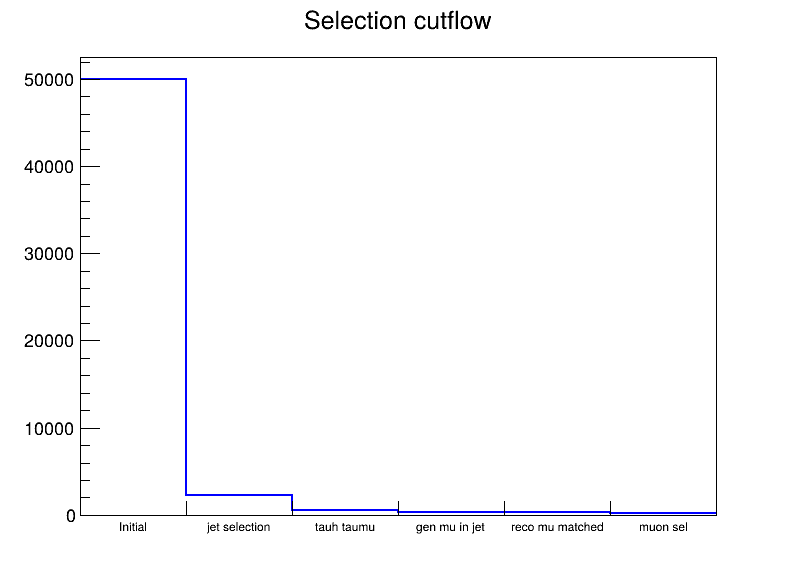

In [14]:
canvas = ROOT.TCanvas("canvas", "canvas", 800, 600)
histo = cutflow.GenerateHistogram()
histo.SetLineColor(ROOT.kBlue)
histo.SetLineWidth(2)
histo.Draw("HIST")
canvas.Update()      # important for interactive display

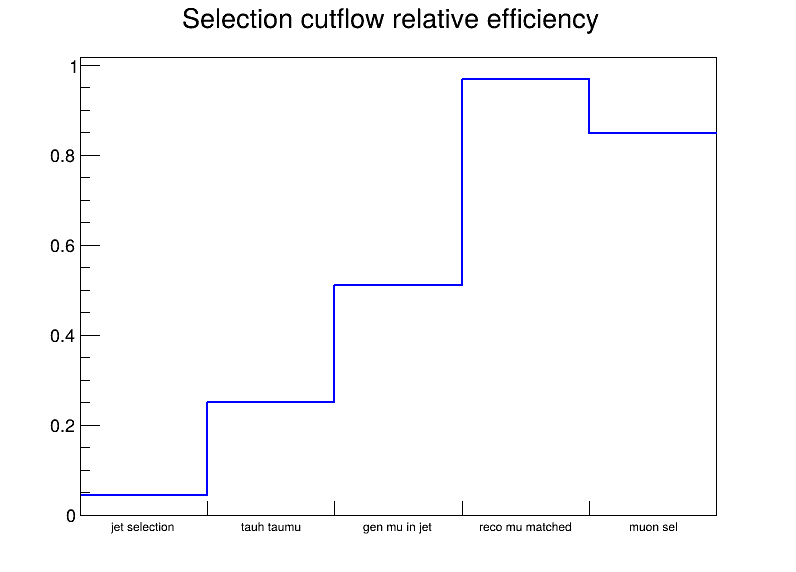

In [15]:
efficiencies = ROOT.TCanvas("efficiencies", "efficiencies", 800, 600)
eff = cutflow.MakeEffHistogram()
eff.SetLineColor(ROOT.kBlue)
eff.SetLineWidth(2)
eff.Draw("HIST")
efficiencies.Update()  # important for interactive display

In [12]:
Ana.filemanager.CloseAll()

True